In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
df = pd.read_csv("AusApparalSales4thQrt2020.csv")
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [3]:
# Check missing values
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Sales_norm', 'Unit_norm']] = scaler.fit_transform(df[['Sales', 'Unit']])

df[['Sales_norm', 'Unit_norm']].head()


,Sales_norm,Unit_norm
0,0.095238,0.095238
1,0.095238,0.095238
2,0.031746,0.031746
3,0.206349,0.206349
4,0.015873,0.015873


In [5]:
df[['Sales', 'Unit']].describe()


,Sales,Unit
count,7560.000000,7560.000000
mean,45013.558201,18.005423
std,32253.506944,12.901403
min,5000.000000,2.000000
25%,20000.000000,8.000000
50%,35000.000000,14.000000
75%,65000.000000,26.000000
max,162500.000000,65.000000


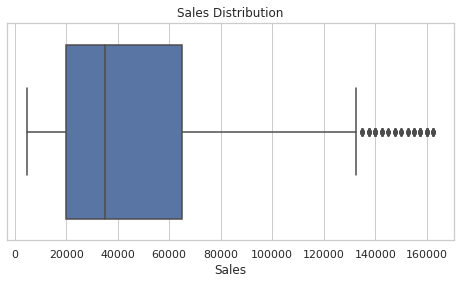

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Sales'])
plt.title("Sales Distribution")
plt.show()


In [7]:
group_sales = df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
group_sales


Group
 Men        85750000
 Women      85442500
 Kids       85072500
 Seniors    84037500
Name: Sales, dtype: int64

In [8]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
state_sales


State
 VIC    105565000
 NSW     74970000
 SA      58857500
 QLD     33417500
 TAS     22760000
 NT      22580000
 WA      22152500
Name: Sales, dtype: int64

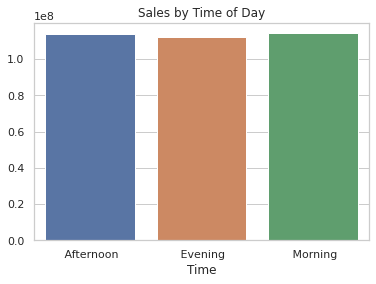

In [9]:
time_sales = df.groupby('Time')['Sales'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=time_sales.index, y=time_sales.values)
plt.title("Sales by Time of Day")
plt.show()


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.resample('M', on='Date')['Sales'].sum()
quarterly_sales = df.resample('Q', on='Date')['Sales'].sum()

monthly_sales, quarterly_sales


(Date
 2020-10-31    114290000
 2020-11-30     90682500
 2020-12-31    135330000
 Freq: M, Name: Sales, dtype: int64,
 Date
 2020-12-31    340302500
 Freq: Q-DEC, Name: Sales, dtype: int64)